This notebook should be able to recreate the algorithm


In [1]:
# Import necessary packages and libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp
import graphlearning as gl
from scipy.special import jn
import scipy.sparse as sps
import scipy.sparse.linalg as spla
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.ndimage import gaussian_filter

In [2]:
def build_custom_knn_graph(X, K=50):
    """
    Constructs the graph G using kNN on the nodes X. Cosine similarity is used to 
    construct the weight matrix.

    Parameters:
    X (numpy.ndarray): Data matrix (p, N).
    K (integer): Integer representing number of nearest neighbors (defaulted to 50).

    Returns:
    G (graph), W (scipy.sparse.csr_matrix): The graph G and its symmetric weight matrix W.
    """

    # Initialize the dimensions (N), nearest neighbors (nbrs), distance metric (ang_dist) 
    # and variance (sigma)
    N = X.shape[0]
    nbrs = NearestNeighbors(n_neighbors=K, metric='cosine', algorithm='brute').fit(X)
    cos_dist, indices = nbrs.kneighbors(X)
    inner_products = np.clip(1.0 - cos_dist, -1.0, 1.0)
    ang_dist = np.arccos(inner_products)
    sigma = np.sqrt(ang_dist[:, K-1])

    row_idx = np.repeat(np.arange(N), K)
    col_idx = indices.flatten()

    sigma_i_expanded = np.repeat(sigma, K)
    sigma_j_expanded = sigma[col_idx]

    denom = sigma_i_expanded * sigma_j_expanded
    denom[denom == 0] = 1e-10

    # Compute weight value
    distances_squared = (ang_dist.flatten())**2
    weights = np.exp(-distances_squared / denom)

    # Construct the similarity matrix W_knn
    W_knn = sps.csr_matrix((weights, (row_idx, col_idx)), shape=(N, N))

    # Make W_knn symmetric
    W = (W_knn + W_knn.T) / 2.0

    # Wrap in a graphlearning graph object
    G = gl.graph(W)

    return G, W

In [3]:
def compute_and_partition_laplacian(W, labeled_indices):
    """
    Computes the unnormalized Graph Laplacian L = D - W and partitions it
    into blocks based on labeled and unlabeled pixel indices.

    Parameters:
    W (scipy.sparse.csr_matrix): The symmetric weight matrix.
    labeled_indices (np.ndarray or list): Indices of the sampled training pixels.

    Returns:
    L, L_ll, L_lu, L_ul, L_uu (scipy.sparse.csr_matrix): The full Laplacian and its blocks.
    """
    N = W.shape[0]

    # 1. Compute the Degree Matrix D
    # The degree of a node is the sum of its edge weights
    # We flatten the matrix to a 1D array to construct the diagonal matrix
    degrees = np.array(W.sum(axis=1)).flatten()
    D = sps.diags(degrees, format='csr')

    # 2. Compute the Unnormalized Graph Laplacian L
    L = D - W

    # 3. Identify unlabeled indices
    all_indices = np.arange(N)
    unlabeled_indices = np.setdiff1d(all_indices, labeled_indices)

    # 4. Partition L into block matrices
    # Because L is a scipy.sparse matrix, we can slice it efficiently using array indexing

    # L_ll: Labeled-to-Labeled
    L_ll = L[labeled_indices, :][:, labeled_indices]

    # L_lu: Labeled-to-Unlabeled
    L_lu = L[labeled_indices, :][:, unlabeled_indices]

    # L_ul: Unlabeled-to-Labeled
    L_ul = L[unlabeled_indices, :][:, labeled_indices]

    # L_uu: Unlabeled-to-Unlabeled
    L_uu = L[unlabeled_indices, :][:, unlabeled_indices]

    return L, L_ll, L_lu, L_ul, L_uu

# --- Example Usage ---
# Assuming W is the sparse matrix from our KNN graph output
# and we randomly selected 50 pixels to act as our "active learning" labels
# N = W.shape[0]
# mock_labeled_indices = np.random.choice(N, size=50, replace=False)
# L, L_ll, L_lu, L_ul, L_uu = compute_and_partition_laplacian(W, mock_labeled_indices)

In [4]:
def project_onto_simplex(V):
    """
    Projects each column of matrix V onto the probability simplex.
    Based on the fast algorithm by Wang and Carreira-Perpinan (2013).

    Parameters:
    V (numpy.ndarray): Matrix of shape (q, N) where q is the number of
                       end-members and N is the number of pixels.

    Returns:
    numpy.ndarray: Projected matrix of the same shape.
    """
    # Sort each column in descending order
    U = np.sort(V, axis=0)[::-1, :]

    # Cumulative sum down the columns
    cssv = np.cumsum(U, axis=0)

    # Array of 1-based indices for the rows
    indices = np.arange(1, V.shape[0] + 1)[:, np.newaxis]

    # Find the condition threshold
    cond = U - (cssv - 1) / indices > 0

    # rho is the maximum index where the condition holds true
    rho = np.max(cond * indices, axis=0)

    # Calculate theta (the shift value) for each column
    theta = (cssv[rho - 1, np.arange(V.shape[1])] - 1) / rho

    # Apply the projection
    return np.maximum(V - theta, 0)

In [5]:
def algo_2_glu(X, X_hat, A_hat, alpha=10.0, k=50):
    """
    Executes the Graph Learning Unmixing (GLU) model (Algorithm 2).

    Parameters:
    X (numpy.ndarray): Unlabeled data matrix (p, N).
    X_hat (numpy.ndarray): Labeled data matrix (p, M).
    A_hat (numpy.ndarray): Labeled abundance matrix / pseudo-labels (q, M).
    alpha (float): Weighting parameter for end-member estimation.
    k (int): Number of nearest neighbors for graph construction.

    Returns:
    A_GLU (numpy.ndarray): Estimated abundance map (q, N).
    S_GLU (numpy.ndarray): Estimated end-member spectrum matrix (p, q).
    """
    p, N = X.shape
    q, M = A_hat.shape

    # --- Initialization ---
    # Combine data to match the paper: \tilde{X} = [\hat{X}, X]
    X_tilde = np.concatenate((X_hat, X), axis=1) # Shape: (p, M + N)

    # Scikit-learn expects (samples, features), so we transpose to (M + N, p)
    G, W = build_custom_knn_graph(X_tilde.T, K=k)

    # Since X_hat is the first M columns, our labeled indices are 0 to M-1
    labeled_indices = np.arange(M)
    L, L_ll, L_lu, L_ul, L_uu = compute_and_partition_laplacian(W, labeled_indices)

    # --- Step 1: Graph Learning Step ---
    # Setup the right-hand side of the transposed linear system: -L_lu^T * A_hat^T
    RHS = -(L_lu.T @ A_hat.T) # Shape will be (N, q)

    A_GL_T = np.zeros((N, q))

    # Solve the sparse linear system for each end-member column
    for i in range(q):
        A_GL_T[:, i], _ = spla.cg(L_uu, RHS[:, i])

    A_GL = A_GL_T.T # Transpose back to get shape (q, N)

    # --- Step 2: Projection ---
    # Project the graph Laplace learning solution onto the probability simplex
    A_GLU = project_onto_simplex(A_GL)

    # --- Step 3: Estimate End-member Spectrum Matrix ---
    term1 = (X @ A_GLU.T) + (alpha**2) * (X_hat @ A_hat.T) # Shape: (p, q)
    term2 = (A_GLU @ A_GLU.T) + (alpha**2) * (A_hat @ A_hat.T) # Shape: (q, q)

    S_GLU_0 = term1 @ np.linalg.inv(term2)

    # Apply non-negativity constraint
    S_GLU = np.maximum(S_GLU_0, 0)

    return A_GLU, S_GLU

In [6]:
def algo_3_grsu(X, X_hat, A_hat, alpha, lam, gamma, rho, max_iters=1000, eps=1e-3, k=50):
    """
    Executes the Graph-Regularized Semi-Supervised Unmixing (GRSU) model (Algorithm 3).

    Parameters:
    X (numpy.ndarray): Unlabeled data matrix (p, N).
    X_hat (numpy.ndarray): Labeled data matrix (p, M).
    A_hat (numpy.ndarray): Labeled abundance matrix / pseudo-labels (q, M).
    alpha (float): Weighting parameter for end-member estimation.
    lam (float): Graph regularization parameter (lambda).
    gamma (float): ADMM penalty parameter for S-T constraint.
    rho (float): ADMM penalty parameter for A-B constraint.
    max_iters (int): Maximum number of ADMM iterations.
    eps (float): Error tolerance for convergence.
    k (int): Number of nearest neighbors for graph construction.

    Returns:
    A_GRSU (numpy.ndarray): Final estimated abundance map (q, N).
    S_GRSU (numpy.ndarray): Final estimated end-member spectrum matrix (p, q).
    """
    p, N = X.shape
    q, M = A_hat.shape

    # --- 1. Graph Construction & Laplacian Partitioning ---
    X_tilde = np.concatenate((X_hat, X), axis=1)
    G, W = build_custom_knn_graph(X_tilde.T, K=k)

    labeled_indices = np.arange(M)
    L, L_ll, L_lu, L_ul, L_uu = compute_and_partition_laplacian(W, labeled_indices)

    # --- 2. Initialization via GLU (Algorithm 2) ---
    A, S = algo_2_glu(X, X_hat, A_hat, alpha, k=k)

    # Initialize ADMM auxiliary and dual variables
    B = np.copy(A)
    B_bar = np.zeros((q, N))
    T_bar = np.zeros((p, q))

    # Pre-compute constants that do not change during iterations
    I_q = np.eye(q)
    I_N_sparse = sps.eye(N, format='csr')

    # Terms in T's update
    X_hat_A_hat_T_alpha2 = (alpha**2) * (X_hat @ A_hat.T)
    A_hat_A_hat_T_alpha2 = (alpha**2) * (A_hat @ A_hat.T)

    # Terms in B's update
    L_B_system = L_uu + (rho / lam) * I_N_sparse
    L_lu_T_A_hat_T = L_lu.T @ A_hat.T # Shape: (N, q)

    Err = 1.0
    i = 0

    # --- 3. ADMM Iteration Loop ---
    while i < max_iters and Err > eps:

        # a) T subproblem update
        term1_T = (X @ A.T) + X_hat_A_hat_T_alpha2 + gamma * (S + T_bar)
        term2_T = (A @ A.T) + A_hat_A_hat_T_alpha2 + gamma * I_q
        T = term1_T @ np.linalg.inv(term2_T)

        # b) S subproblem update
        S_new = np.maximum(T - T_bar, 0)

        # c) A subproblem update
        term1_A = np.linalg.inv((S_new.T @ S_new) + rho * I_q)
        term2_A = (S_new.T @ X) + rho * (B - B_bar)
        A_unproj = term1_A @ term2_A
        A_new = project_onto_simplex(A_unproj)

        # d) B subproblem update (Graph Regularized Laplace Learning)
        # We solve the transposed system: L_B_system * B^T = RHS_B
        RHS_B = -L_lu_T_A_hat_T + (rho / lam) * (A_new.T + B_bar.T)
        B_new_T = np.zeros((N, q))

        for j in range(q):
            B_new_T[:, j], _ = spla.cg(L_B_system, RHS_B[:, j])
        B_new = B_new_T.T

        # e) Update dual variables
        B_bar_new = B_bar + (A_new - B_new)
        T_bar_new = T_bar + (S_new - T)

        # f) Calculate convergence error
        # Protect against division by zero in the denominator
        norm_S = np.linalg.norm(S, 'fro')
        norm_A = np.linalg.norm(A, 'fro')

        err_S = np.linalg.norm(S_new - S, 'fro') / norm_S if norm_S > 0 else 0
        err_A = np.linalg.norm(A_new - A, 'fro') / norm_A if norm_A > 0 else 0

        Err = max(err_S, err_A)

        # g) Advance state for next iteration
        S = S_new
        A = A_new
        B = B_new
        B_bar = B_bar_new
        T_bar = T_bar_new

        i += 1

    return A, S

In [7]:
def compute_vopt_acquisition(V, Lambda_mat, labeled_indices, gamma=0.1):
    """
    Computes the Variance Optimality (VOpt) acquisition function for all nodes.

    Parameters:
    V (numpy.ndarray): Eigenvectors of the Laplacian (N, M_eigs).
    Lambda_mat (numpy.ndarray): Diagonal eigenvalue matrix (M_eigs, M_eigs).
    labeled_indices (list or np.ndarray): Indices of currently labeled nodes.
    gamma (float): Positive constant (paper uses 0.1).

    Returns:
    numpy.ndarray: VOpt scores for all nodes.
    """
    N, M_eigs = V.shape

    # 1. Compute the projection matrix component: (1/gamma^2) * V^T * P^T * P * V
    # Instead of building a massive projection matrix P, we can just slice V!
    # P * V is exactly equivalent to taking the rows of V corresponding to labeled_indices.
    V_labeled = V[labeled_indices, :]

    # Calculate V^T * P^T * P * V
    V_proj_T_V_proj = V_labeled.T @ V_labeled

    # 2. Compute the Gaussian correlation matrix C
    # C = (Lambda + (1/gamma^2) * V^T * P^T * P * V)^-1
    C_inv = Lambda_mat + (1.0 / (gamma**2)) * V_proj_T_V_proj
    C = np.linalg.inv(C_inv) # C is small (M_eigs x M_eigs), so direct inversion is fast

    # 3. Compute VOpt for all nodes
    # A_VOpt(x_k) = ||C v_k||_2^2 / (gamma^2 + v_k^T C v_k)
    # v_k is the k-th row of V

    # We can vectorize this to avoid a slow Python for-loop over N nodes
    # C @ V.T gives a matrix where columns are (C v_k). Shape: (M_eigs, N)
    CV_T = C @ V.T

    # ||C v_k||_2^2 is the squared L2 norm of each column
    numerator = np.sum(CV_T**2, axis=0)

    # v_k^T C v_k can be found by taking the dot product of V with (C V.T).T
    # This is equivalent to row-wise dot product of V and (V @ C.T)
    denominator = (gamma**2) + np.sum(V * (V @ C.T), axis=1)

    vopt_scores = numerator / denominator

    return vopt_scores

In [34]:
def algo_1_active_learning(X, W, m_initial=5, M_total=40, num_eigs=50, gamma=0.1):
    """
    Executes Algorithm 1: Graph-based Active Learning to sample labeled pixels.

    Parameters:
    X (numpy.ndarray): Data matrix (p, N).
    W (scipy.sparse.csr_matrix): KNN weight matrix.
    m_initial (int): Initial number of randomly sampled pixels.
    M_total (int): Total number of labeled pixels to acquire.
    num_eigs (int): Number of eigenvectors to compute for the low-rank approximation.
    gamma (float): Constant for the acquisition function.

    Returns:
    list: Final list of M_total selected pixel indices.
    """
    N = W.shape[0]

    # 1. Compute the Graph Laplacian
    degrees = np.array(W.sum(axis=1)).flatten()
    D = sps.diags(degrees, format='csr')
    L = D - W

    # 2. Compute truncated eigen-decomposition of L
    # We want the smallest algebraic eigenvalues ('SA' or 'SM')
    # Use shift-invert mode (sigma=0) to reliably find eigenvalues near zero
    eigenvalues, V = spla.eigsh(L, k=num_eigs, which='SM')

    # Ensure eigenvalues are non-negative (Laplacian property, but float math can drift)
    eigenvalues = np.maximum(eigenvalues, 0)
    Lambda_mat = np.diag(eigenvalues)

    # 3. Initialize label set randomly
    # Ensure we don't pick duplicate initial indices
    labeled_indices = list(np.random.choice(N, size=m_initial, replace=False))

    # 4. Active Learning Iteration
    while len(labeled_indices) < M_total:

        # Calculate acquisition function scores
        scores = compute_vopt_acquisition(V, Lambda_mat, labeled_indices, gamma=gamma)

        # We only want to select from UNLABELED nodes
        # Force the score of already labeled nodes to -infinity so they aren't picked again
        scores[labeled_indices] = -np.inf

        # Sequential Active Learning: Select the single node with the highest score
        best_node_idx = np.argmax(scores)

        # Update the current label set
        labeled_indices.append(best_node_idx)

    return labeled_indices

# --- Note on Pseudo-Labels ---
# Once algo_1_active_learning returns the list of indices, you would extract
# X_hat = X[:, labeled_indices].
# You would then acquire A_hat (the pseudo-labels) by either human inspection
# or by thresholding an exact abundance map for those specific pixels.

In [35]:
def generate_one_hot_labels(A_exact):
    """
    Converts exact abundance vectors into one-hot pseudo-labels.
    This mimics an expert identifying the most significant end-member[cite: 322].

    Parameters:
    A_exact (numpy.ndarray): Exact abundance matrix (q, M).

    Returns:
    numpy.ndarray: One-hot encoded pseudo-label matrix (q, M).
    """
    q, M = A_exact.shape
    A_oh = np.zeros((q, M))

    # Find the index of the maximum abundance for each pixel (column)
    max_indices = np.argmax(A_exact, axis=0)

    # Set the dominant material to 1.0, rest remain 0.0
    A_oh[max_indices, np.arange(M)] = 1.0

    return A_oh

In [36]:
def run_unmixing_pipeline_example(X, A_gt, S_gt):
    # ==========================================
    # Phase 0: Load Data (Mocking Jasper Ridge)
    # ==========================================
    #print("Loading data...")
    #N = 10000  # Number of pixels (e.g., 100x100 image)
    #p = 198    # Number of spectral bands [cite: 286]
    #q = 4      # Number of latent end-members (Tree, Water, Dirt, Road) [cite: 287, 288]

    # Mock full hyperspectral image X: shape (p, N)
    #X = np.random.rand(p, N, seed=42)

    # Mock ground-truth abundance map (only used to simulate human labeling)
    #A_gt = np.random.dirichlet(np.ones(q), size=N, seed=42).T

    # ==========================================
    # Phase 1: Active Learning (Algorithm 1)
    # ==========================================
    print("Building initial graph for Active Learning...")
    # Scikit-learn expects (samples, features), so we pass X.T
    G, W = build_custom_knn_graph(X.T, K=50)

    print("Running Active Learning...")
    # Start with 1 random pixel per material (m=4), sample up to 0.4% of total pixels (M=40) [cite: 323]
    labeled_indices = algo_1_active_learning(X, W, m_initial=4, M_total=40, num_eigs=50)

    # ==========================================
    # Phase 2: Extract Training Data
    # ==========================================
    print("Extracting training data and generating pseudo-labels...")
    # Extract the spectral signatures for the selected pixels
    X_hat = X[:, labeled_indices]

    # Extract ground-truth abundances and convert to One-Hot pseudo-labels [cite: 321, 322]
    A_hat_exact = A_gt[:, labeled_indices]
    A_hat_OH = generate_one_hot_labels(A_hat_exact)

    # ==========================================
    # Phase 3: Semi-Supervised Unmixing
    # ==========================================
    print("Running GRSU (and GLU) Unmixing...")

    # Hyperparameters based on the Jasper Ridge dataset in Table II [cite: 339, 340]
    alpha = 10.0
    lam = 1.0
    gamma = 1.0
    rho = 1.0

    # Note: The paper mentions an overlap between X_hat and X, but updates
    # the abundance map for all pixels in X anyway.
    A_final, S_final = algo_3_grsu(
        X=X,
        X_hat=X_hat,
        A_hat=A_hat_OH,
        alpha=alpha,
        lam=lam,
        gamma=gamma,
        rho=rho,
        max_iters=1000,
        eps=1e-3,
        k=50
    )

    print("Pipeline Complete!")
    print(f"Final Abundance Map Shape: {A_final.shape}")
    print(f"Final End-member Matrix Shape: {S_final.shape}")

    return A_final, S_final



In [79]:
samples = 2000
channels = 300
np.random.seed(42)


L = np.random.uniform(0,1,samples)
A = np.array([L,1-L])


s_1 = gaussian_filter(np.random.uniform(0,1,channels),2)
s_2 = gaussian_filter(np.random.uniform(0,1,channels),2)

S_T = np.array([s_1,s_2])

S = S_T.T



X=S@A
error_std = 0.05

E = np.random.normal(loc=0.0, scale=error_std, size=X.shape)

X=X+E


A_f, S_f = run_unmixing_pipeline_example(X, A, S)



Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GRSU (and GLU) Unmixing...
Pipeline Complete!
Final Abundance Map Shape: (2, 2000)
Final End-member Matrix Shape: (300, 2)


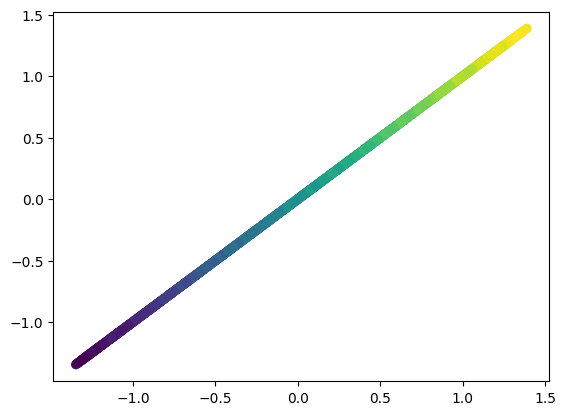

In [80]:
from sklearn.decomposition import PCA

pca1 = PCA(n_components=2)
X_pca1 = pca1.fit_transform(X.T)

plt.scatter(X_pca1[:,0],X_pca1[:,0],c=A[0])


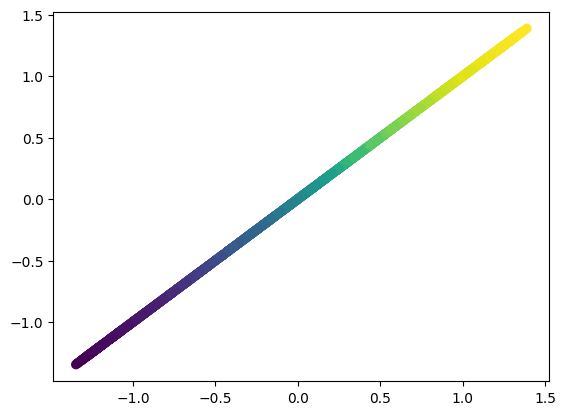

In [81]:
plt.scatter(X_pca1[:,0],X_pca1[:,0],c=A_f[0])

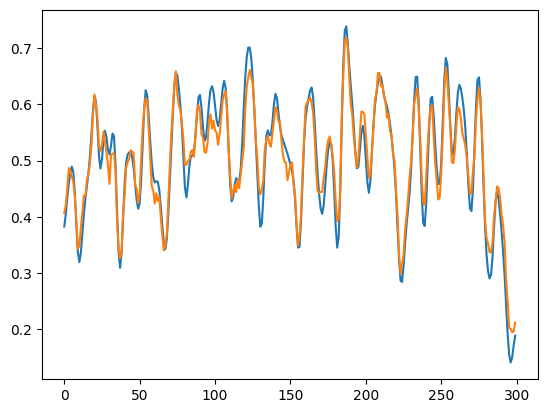

In [82]:
plt.plot(range(len(S[:,0])),S[:,0])
plt.plot(range(len(S_f[:,0])),S_f[:,0])


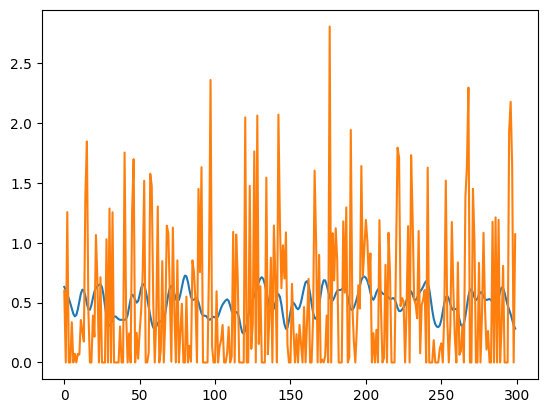

In [78]:
plt.plot(range(len(S[:,0])),S[:,1])
plt.plot(range(len(S_f[:,0])),S_f[:,1])